## Import Libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Data 

In [2]:
df = pd.read_csv("/Users/blaketracy/Downloads/FantasyPros_2026_Draft_ALL_Rankings.csv")

df.head()

,RK,TIERS,PLAYER NAME,TEAM,POS,BEST,WORST,AVG.,STD.DEV,ECR VS. ADP
0,1.0,1,Ja'Marr Chase,CIN,WR1,1.0,3.0,1.1,0.5,-
1,2.0,1,Bijan Robinson,ATL,RB1,2.0,5.0,2.5,1.1,-
2,3.0,1,Puka Nacua,LAR,WR2,3.0,6.0,3.6,0.8,-
3,4.0,1,Jaxon Smith-Njigba,SEA,WR3,3.0,4.0,3.7,0.5,-
4,5.0,2,Jahmyr Gibbs,DET,RB2,2.0,7.0,4.6,1.6,-


## Clean Data 

In [3]:
df = df.rename(columns={
    "RK": "rank",
    "PLAYER NAME": "player",
    "POS": "position",
    "AVG.": "avg_rank"
})

df = df[["rank", "player", "position", "avg_rank"]]

df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
df["avg_rank"] = pd.to_numeric(df["avg_rank"], errors="coerce")

df = df.dropna()

df.head()

,rank,player,position,avg_rank
0,1.0,Ja'Marr Chase,WR1,1.1
1,2.0,Bijan Robinson,RB1,2.5
2,3.0,Puka Nacua,WR2,3.6
3,4.0,Jaxon Smith-Njigba,WR3,3.7
4,5.0,Jahmyr Gibbs,RB2,4.6


## Create Value Metric

In [4]:
df["value"] = df["avg_rank"] - df["rank"]

df.head()

,rank,player,position,avg_rank,value
0,1.0,Ja'Marr Chase,WR1,1.1,0.1
1,2.0,Bijan Robinson,RB1,2.5,0.5
2,3.0,Puka Nacua,WR2,3.6,0.6
3,4.0,Jaxon Smith-Njigba,WR3,3.7,-0.3
4,5.0,Jahmyr Gibbs,RB2,4.6,-0.4


## Filter Top 100

In [5]:
df_top100 = df[df["rank"] <= 100].copy()

df_top100.head()

,rank,player,position,avg_rank,value
0,1.0,Ja'Marr Chase,WR1,1.1,0.1
1,2.0,Bijan Robinson,RB1,2.5,0.5
2,3.0,Puka Nacua,WR2,3.6,0.6
3,4.0,Jaxon Smith-Njigba,WR3,3.7,-0.3
4,5.0,Jahmyr Gibbs,RB2,4.6,-0.4


## Find Values

In [6]:
overrated = df_top100.sort_values("value", ascending=False)
underrated = df_top100.sort_values("value")

print("Most overrated (Top 100):")
print(overrated.head(20))

print("\nMost underrated (Top 100):")
print(underrated.head(20))

Most overrated (Top 100):
     rank               player position  avg_rank  value
66   66.0  Marvin Harrison Jr.     WR31      71.0    5.0
67   67.0       Bhayshul Tuten     RB25      71.8    4.8
35   35.0    Luther Burden III     WR18      39.7    4.7
73   73.0       Caleb Williams      QB9      77.1    4.1
36   36.0          Zay Flowers     WR19      40.0    4.0
68   68.0          Jaxson Dart      QB7      71.9    3.9
63   63.0        D'Andre Swift     RB24      66.7    3.7
69   69.0     Chris Godwin Jr.     WR32      72.4    3.4
64   64.0         Tucker Kraft      TE5      67.4    3.4
37   37.0        Ladd McConkey     WR20      40.4    3.4
65   65.0     Courtland Sutton     WR30      68.2    3.2
74   74.0            RJ Harvey     RB26      77.2    3.2
100  99.0   Patrick Mahomes II     QB13     102.1    3.1
62   62.0     David Montgomery     RB23      65.1    3.1
61   61.0     Quinshon Judkins     RB22      64.1    3.1
71   71.0           DK Metcalf     WR33      73.9    2.9
11   

## Visualizations 

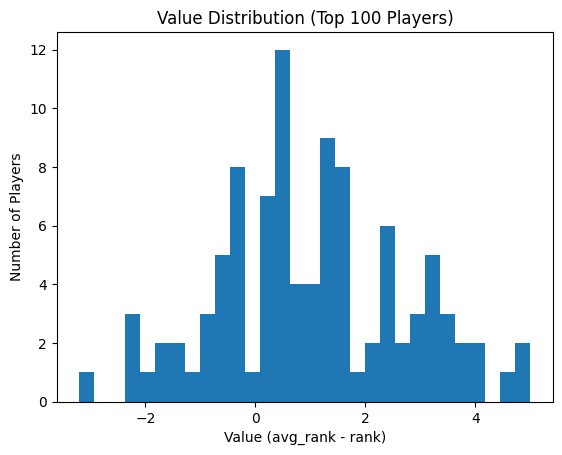

<Figure size 640x480 with 0 Axes>

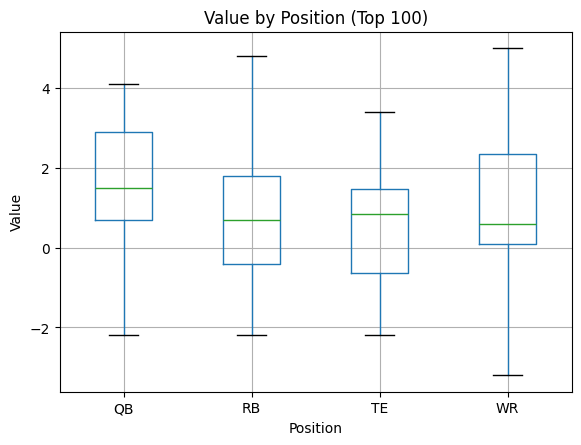

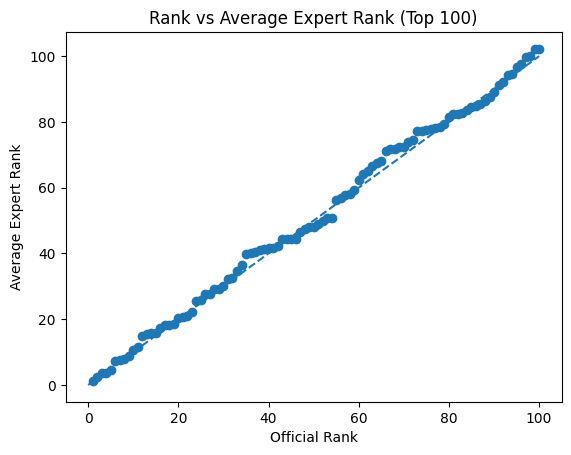

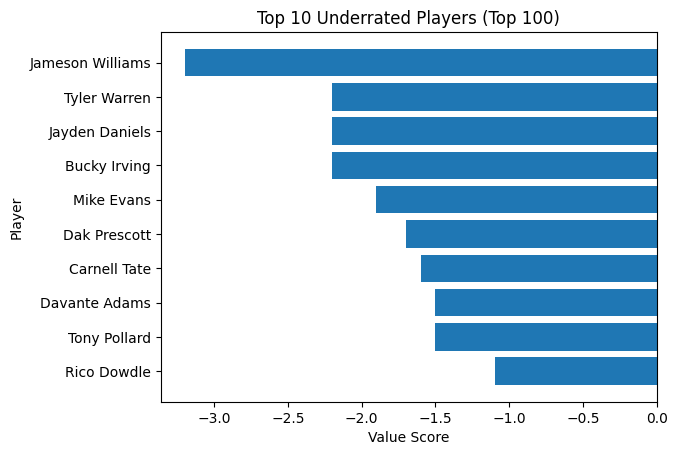

In [7]:
df_top100["position_group"] = df_top100["position"].str.extract(r"([A-Z]+)")
plt.figure()
plt.hist(df_top100["value"], bins=30)

plt.title("Value Distribution (Top 100 Players)")
plt.xlabel("Value (avg_rank - rank)")
plt.ylabel("Number of Players")

plt.show()
plt.figure()
df_top100.boxplot(column="value", by="position_group")

plt.title("Value by Position (Top 100)")
plt.suptitle("")
plt.xlabel("Position")
plt.ylabel("Value")

plt.show()

plt.figure()

plt.scatter(df_top100["rank"], df_top100["avg_rank"])

plt.plot([0, 100], [0, 100], linestyle='--')

plt.title("Rank vs Average Expert Rank (Top 100)")
plt.xlabel("Official Rank")
plt.ylabel("Average Expert Rank")

plt.show()
top_underrated = df_top100.sort_values("value").head(10)

plt.figure()
plt.barh(top_underrated["player"], top_underrated["value"])

plt.title("Top 10 Underrated Players (Top 100)")
plt.xlabel("Value Score")
plt.ylabel("Player")

plt.gca().invert_yaxis()

plt.show()

## Key Takeaways 

- Most players cluster near zero value, indicating strong overall agreement between official rankings and expert consensus.
- Clear outliers exist, highlighting players who may be significantly overvalued or undervalued.
- Undervalued players (experts rank them higher than official rankings) represent potential draft opportunities.
- Overvalued players may carry more risk if drafted above consensus expectations.
- Positional differences suggest some positions have greater ranking uncertainty than others.
- Focusing on the top 100 players improves relevance by targeting realistic draft decisions.